# 09 — End-to-End Linear Regression Project  
*California Housing Prices: from raw data → model → mini "deployment".*

**Goal:**  
Build a complete regression pipeline on a real-world dataset:

- Load and inspect a real housing dataset (California census tracts).  
- Perform EDA: distributions, correlations, feature–target relationships.  
- Do basic preprocessing and train–validation splitting.  
- Train and compare several linear models (OLS, Ridge, Lasso).  
- Evaluate with MSE / MAE / R², plus visual diagnostics.  
- Wrap the best model into a tiny prediction function as a mini “deployment”.

This project glues together ideas from:

- Probability & statistics (noise, variance, metrics)  
- Linear algebra & gradient-based optimization  
- Basic ML (regression, regularization, model selection)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (6.4, 3.8)
plt.rcParams["axes.titlesize"] = 12

## 1. Dataset & Problem Statement

We’ll use California housing data:

- Each row = a census block group in California.
- Features (per block): median income, house age, average rooms, population, latitude/longitude, etc.
- Target: `MedHouseVal` — median house value (in \$100,000s).

**Task:**  
Given block-level features, predict the median house value.

This is a tabular regression problem, very typical in applied ML.

In [ ]:
# Load into DataFrame
cal = fetch_california_housing(as_frame=True)
df = cal.frame.copy()

print("Shape:", df.shape)
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## 2. Exploratory Data Analysis (EDA)

Questions we’ll quickly explore:

- What are the ranges and scales of each feature?
- Are there obvious outliers or heavy skew?
- Which features correlate most with house value?
- How does the target distribution look?

This guides preprocessing (e.g., scaling, transforms) and model choice.

In [ ]:
# Descriptive Stats & Target Distribution
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


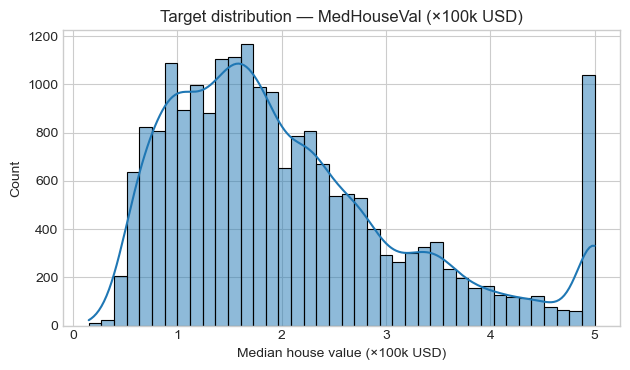

In [ ]:
# Target Histogram
plt.figure()
sns.histplot(df["MedHouseVal"], kde=True, bins=40)
plt.title("Target distribution — MedHouseVal (×100k USD)")
plt.xlabel("Median house value (×100k USD)")
plt.tight_layout()
plt.show()

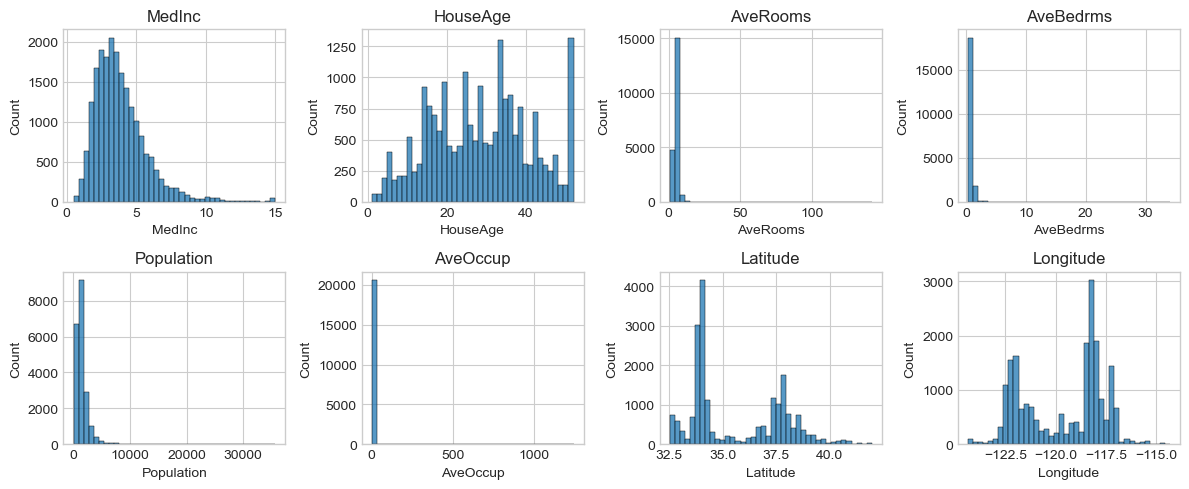

In [ ]:
# Feature Histograms
fig, axes = plt.subplots(2, 4, figsize=(12, 5))
axes = axes.ravel()

for col, ax in zip(df.columns[:-1], axes): # all features except target
    sns.histplot(df[col], bins=40, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Correlation with target
corr = df.corr(numeric_only=True)
corr["MedHouseVal"].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

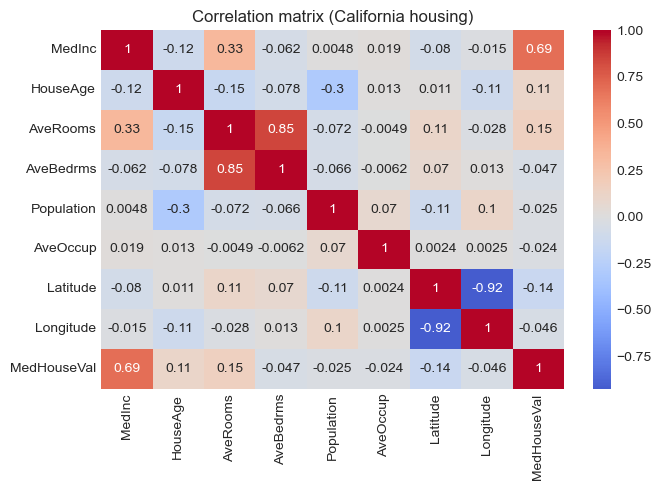

In [10]:
# Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation matrix (California housing)")
plt.tight_layout()
plt.show()

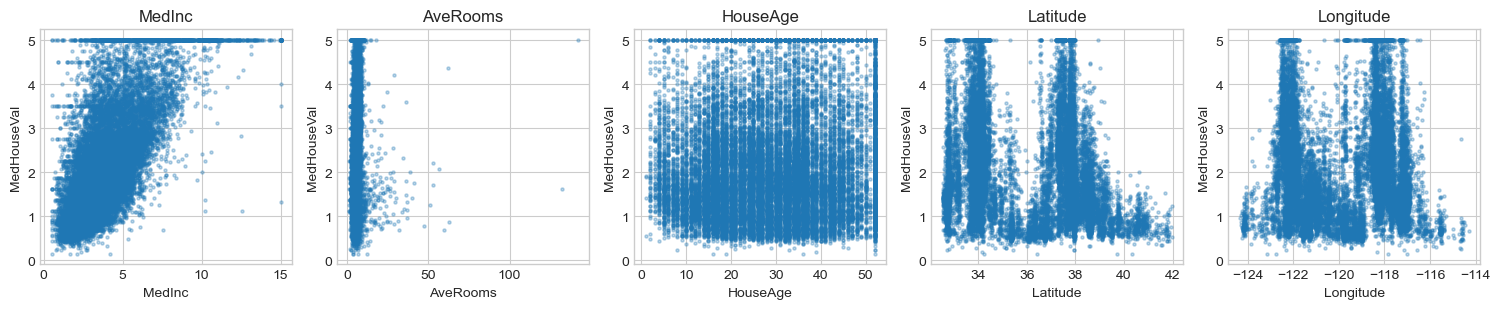

In [11]:
# Key Feature vs Target Scatter
key_features = ["MedInc", "AveRooms", "HouseAge", "Latitude", "Longitude"]

fig, axes = plt.subplots(1, len(key_features), figsize=(3*len(key_features), 3.2))
for col, ax in zip(key_features, axes):
    ax.scatter(df[col], df["MedHouseVal"], s=5, alpha=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel("MedHouseVal")
    ax.set_title(col)

plt.tight_layout()
plt.show()

## 3. Train/Validation Split & Baseline

We’ll:

1. Split data into train and test sets (80/20).
2. Build a naive baseline that always predicts the *training* mean of the target.
3. Compare all later models against this baseline using:

- MSE (Mean Squared Error)  
- MAE (Mean Absolute Error)  
- R² (coefficient of determination)

In [12]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# Baseline: predict training mean
baseline_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

def metrics_dict(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2":  r2_score(y_true, y_pred),
    }

print("Baseline metrics:", {k: round(v, 3) for k, v in metrics_dict(y_test, baseline_pred).items()})

Train shape: (16512, 8) Test shape: (4128, 8)
Baseline metrics: {'MSE': 1.311, 'MAE': 0.906, 'R2': -0.0}


## 4. Preprocessing & Linear Models

We’ll build three linear models wrapped in Pipelines:

1. **OLS** — `LinearRegression` with feature standardization.
2. **Ridge** — L2-regularized regression (controls weight magnitude).
3. **Lasso** — L1-regularized regression (encourages sparsity).

All preprocessing (here, `StandardScaler`) happens *inside* the pipeline to avoid data leakage.

In [13]:
models = {
    "OLS": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ]),
    "Ridge(α=1.0)": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    "Lasso(α=0.001)": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=10_000))
    ]),
}

results = []

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    m = metrics_dict(y_test, y_pred)
    m = {k: round(v, 4) for k, v in m.items()}
    m["Model"] = name
    results.append(m)

results_df = pd.DataFrame(results).set_index("Model").sort_values("R2", ascending=False)
results_df

,MSE,MAE,R2
Model,,,
Lasso(α=0.001),0.5545,0.5331,0.5769
OLS,0.5559,0.5332,0.5758
Ridge(α=1.0),0.5559,0.5332,0.5758


Best model by R² on test set: Lasso(α=0.001)
MSE    0.5545
MAE    0.5331
R2     0.5769
Name: Lasso(α=0.001), dtype: float64


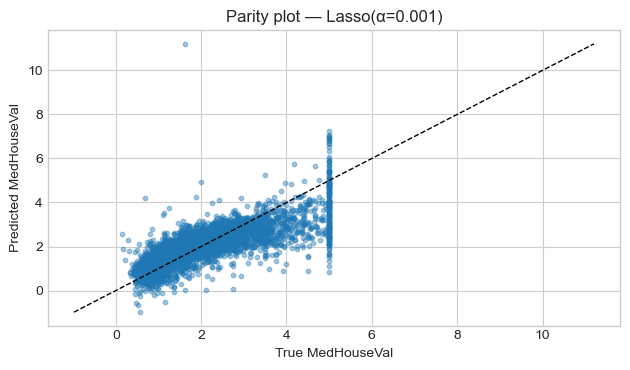

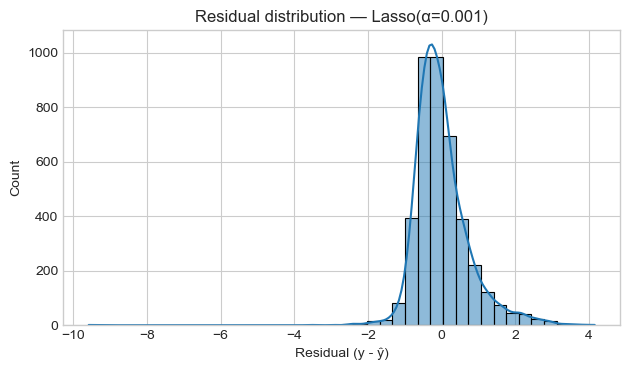

In [14]:
# Pick Best Model & Diagnostics
best_name = results_df["R2"].idxmax()
best_pipeline = models[best_name]
print(f"Best model by R² on test set: {best_name}")
print(results_df.loc[best_name])

# Predictions from best model
y_pred_best = best_pipeline.predict(X_test)

# Parity plot: y_true vs y_pred
plt.figure()
plt.scatter(y_test, y_pred_best, s=10, alpha=0.4)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, "k--", linewidth=1)
plt.title(f"Parity plot — {best_name}")
plt.xlabel("True MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.tight_layout()
plt.show()

# Residual histogram
residuals = y_test - y_pred_best
plt.figure()
sns.histplot(residuals, bins=40, kde=True)
plt.title(f"Residual distribution — {best_name}")
plt.xlabel("Residual (y - ŷ)")
plt.tight_layout()
plt.show()

## 5. Cross-Validation & Hyperparameters (Ridge)

We’ll tune the Ridge regularization strength $\alpha$ using cross-validation on the training set.

- Small $\alpha$: low regularization, risk of overfitting.  
- Large $\alpha$: stronger shrinkage, may underfit.

We’ll:

1. Try a grid of $\alpha$ values.
2. Compute 5-fold CV $R^2$ for each.
3. Pick the best $\alpha$ and compare against our previous best model.

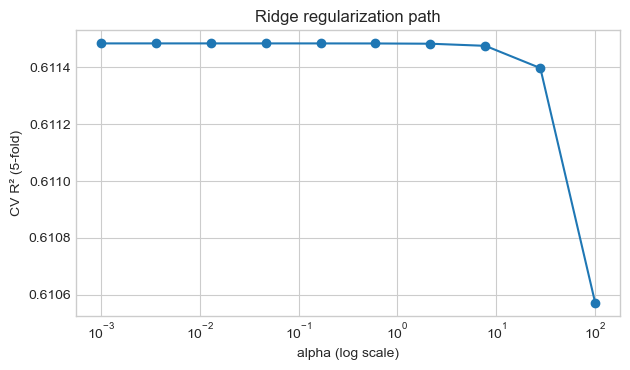

Best alpha by CV: 0.001
Best mean CV R²: 0.6115


In [15]:
alphas = np.logspace(-3, 2, 10)
cv_scores = []

for a in alphas:
    ridge_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=a, random_state=RANDOM_STATE))
    ])
    scores = cross_val_score(
        ridge_pipe, X_train, y_train, cv=5,
        scoring="r2", n_jobs=-1
    )
    cv_scores.append(scores.mean())

cv_scores = np.array(cv_scores)

plt.figure()
plt.semilogx(alphas, cv_scores, marker="o")
plt.xlabel("alpha (log scale)")
plt.ylabel("CV R² (5-fold)")
plt.title("Ridge regularization path")
plt.tight_layout()
plt.show()

best_alpha = float(alphas[cv_scores.argmax()])
print("Best alpha by CV:", best_alpha)
print("Best mean CV R²:", round(cv_scores.max(), 4))

In [16]:
# Train Final Ridge & Compare
ridge_best = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", Ridge(alpha=best_alpha, random_state=RANDOM_STATE))
])
ridge_best.fit(X_train, y_train)
y_pred_ridge_best = ridge_best.predict(X_test)
metrics_ridge_best = {k: round(v, 4) for k, v in metrics_dict(y_test, y_pred_ridge_best).items()}
metrics_ridge_best

{'MSE': 0.5559, 'MAE': 0.5332, 'R2': 0.5758}

## 6. Tiny “Deployment” — Prediction Helper

In a real project, the trained pipeline would be:

- Saved to disk (e.g., `joblib.dump`)  
- Loaded inside an API server (FastAPI / Flask) or a batch script  
- Used to serve predictions for new data

Here, we’ll simulate a *single prediction* function:

- Train the chosen model on all data (train + test).  
- Define `predict_median_value(features_dict)` that takes a Python `dict` and returns a prediction.  
- Try it on a realistic example (e.g., middle-income block near the coast).

In [ ]:
deployed_model = ridge_best

# Fit on full dataset
deployed_model.fit(X, y)

feature_names = list(X.columns)
print("Features:", feature_names)

def predict_median_value(features):
    """
    features: dict mapping feature name -> value
              any missing feature will be filled with dataset median.
    returns: predicted median house value in 100k USD.
    """
    x = df[feature_names].median().to_dict() # start from medians
    x.update(features) # override with user values
    x_df = pd.DataFrame([x], columns=feature_names)
    pred = deployed_model.predict(x_df)[0]
    return float(pred)

# Example: relatively high-income coastal block
example_features = {
    "MedInc": 6.0, # median income (~$60k)
    "HouseAge": 20.0,
    "AveRooms": 5.5,
    "AveBedrms": 1.0,
    "Population": 800.0,
    "AveOccup": 2.5,
    "Latitude": 34.0, # SoCal-ish
    "Longitude": -118.3, # near LA
}

pred_val = predict_median_value(example_features)
print(f"Predicted median house value: {pred_val:.3f} × 100k USD (~${pred_val*100_000:,.0f})")

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Predicted median house value: 2.987 × 100k USD (~$298,739)


## 7. Project Summary & Next Steps

- Loaded and explored the California housing dataset (real census data).  
- Performed EDA: distributions, correlations, and key feature–target plots.  
- Built a train/test split and a mean baseline for comparison.  
- Trained and evaluated OLS, Ridge, and Lasso models with proper scaling.  
- Used Ridge + cross-validation to choose a regularization strength.  
- Wrapped the final model into a small prediction helper, mimicking deployment.

This project solidifies:

- How linear regression behaves on real, noisy data.  
- How to structure an end-to-end ML workflow (EDA → preprocessing → modeling → evaluation → deployment sketch).  

> **Next:** Build `10_cnn_image_classification_project.ipynb` for a vision-based classification task. Then move on to `Phase 1 — Fundamentals` (MDPs, Bellman equations, DP, Monte Carlo, TD).